In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")

# 加载清洗后的 CSV
df = pd.read_csv("../data/steam_games_cleaned.csv")

print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68458 entries, 0 to 68457
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appID                     68458 non-null  int64  
 1   name                      68458 non-null  object 
 2   short_description         68458 non-null  object 
 3   tags                      68458 non-null  object 
 4   categories                68458 non-null  object 
 5   genres                    68458 non-null  object 
 6   screenshots               68429 non-null  object 
 7   movies                    66079 non-null  object 
 8   required_age              68458 non-null  int64  
 9   price                     68458 non-null  float64
 10  languages                 68458 non-null  object 
 11  reviews                   9341 non-null   object 
 12  website                   34495 non-null  object 
 13  positive                  68458 non-null  int64  
 14  negati

In [31]:
# 数据规模
print("总共有 {} 条游戏记录，包含 {} 个字段".format(df.shape[0], df.shape[1]))

# 缺失值统计
print(df.isna().sum())

# 核心统计量
print(df[['price','required_age','positive','negative','recommendations',
          'average_playtime_forever','median_playtime_forever','metacritic_score']].describe())


总共有 68458 条游戏记录，包含 20 个字段
appID                           0
name                            0
short_description               0
tags                            0
categories                      0
genres                          0
screenshots                    29
movies                       2379
required_age                    0
price                           0
languages                       0
reviews                     59117
website                     33963
positive                        0
negative                        0
recommendations                 0
average_playtime_forever        0
median_playtime_forever         0
header_image                    0
metacritic_score                0
dtype: int64
              price  required_age      positive       negative  \
count  68458.000000  68458.000000  6.845800e+04   68458.000000   
mean       8.021743      0.337725  1.166298e+03     199.672865   
std       10.539416      2.333325  2.695185e+04    5102.990159   
min        0.0000

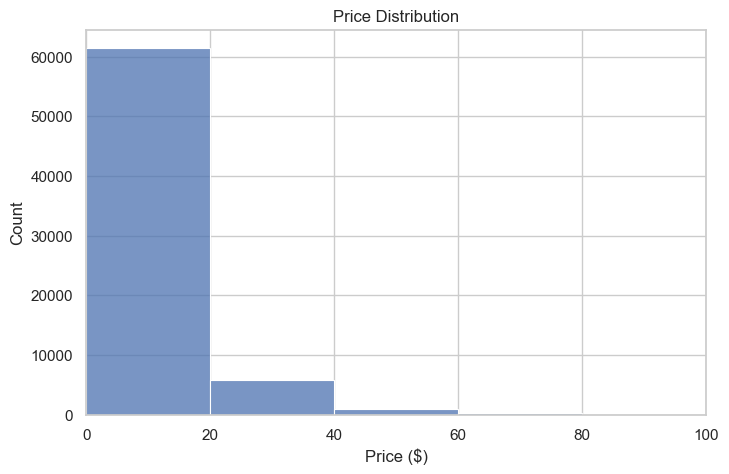

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50, kde=False)
plt.title("Price Distribution")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.xlim(0, 100)  # 大部分游戏价格在100以下
plt.show()


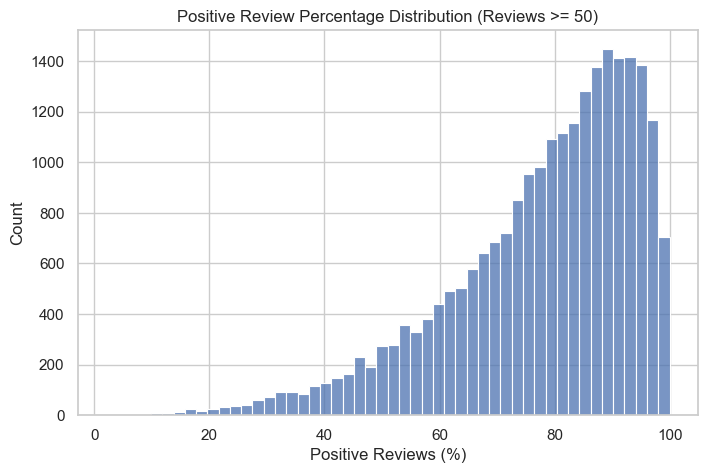

In [34]:
# 计算好评百分比
df['total_reviews'] = df['positive'] + df['negative']
df['positive_percent'] = df.apply(
    lambda row: (row['positive'] / row['total_reviews'] * 100)
                if row['total_reviews'] > 0 else 0, axis=1
)

# 绘制好评百分比分布
# 只保留评价总数 >= 50 的游戏
df_filtered = df[df['total_reviews'] >= 50]

plt.figure(figsize=(8,5))
sns.histplot(df_filtered['positive_percent'], bins=50, kde=False)
plt.title("Positive Review Percentage Distribution (Reviews >= 50)")
plt.xlabel("Positive Reviews (%)")
plt.ylabel("Count")
plt.show()



In [35]:
# 星露谷的记录
stardew = df[df['name'].str.lower() == 'stardew valley']

if not stardew.empty:
    positive = stardew.iloc[0]['positive']
    negative = stardew.iloc[0]['negative']
    total = positive + negative
    positive_percent = (positive / total * 100) if total > 0 else 0
    print(f"Stardew Valley 好评数量: {positive}")
    print(f"Stardew Valley 差评数量: {negative}")
    print(f"Stardew Valley 好评百分比: {positive_percent:.2f}%")
else:
    print("未找到《Stardew Valley》的数据")


Stardew Valley 好评数量: 475785
Stardew Valley 差评数量: 8983
Stardew Valley 好评百分比: 98.15%


Top 10 Tags: [('Indie', 42529), ('Singleplayer', 37975), ('Action', 37928), ('Adventure', 31870), ('Casual', 29487), ('2D', 25495), ('RPG', 19886), ('Strategy', 19678), ('Platformer', 16424), ('3D', 16383)]


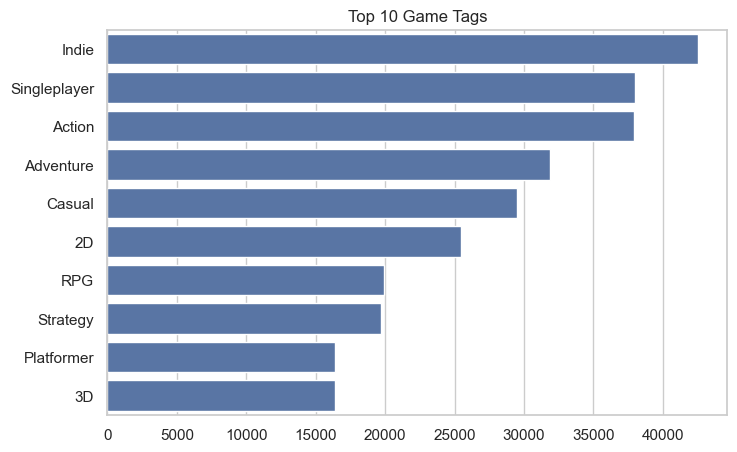

In [36]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# 统计标签出现次数
all_tags = " ".join(df['tags'].dropna()).split()
tag_counts = Counter(all_tags)
top_tags = tag_counts.most_common(10)
print("Top 10 Tags:", top_tags)

# 可视化前 10 标签
tags, counts = zip(*top_tags)
plt.figure(figsize=(8, 5))
sns.barplot(x=list(counts), y=list(tags))
plt.title("Top 10 Game Tags")
plt.xlabel("出现次数")
plt.ylabel("标签")
plt.show()


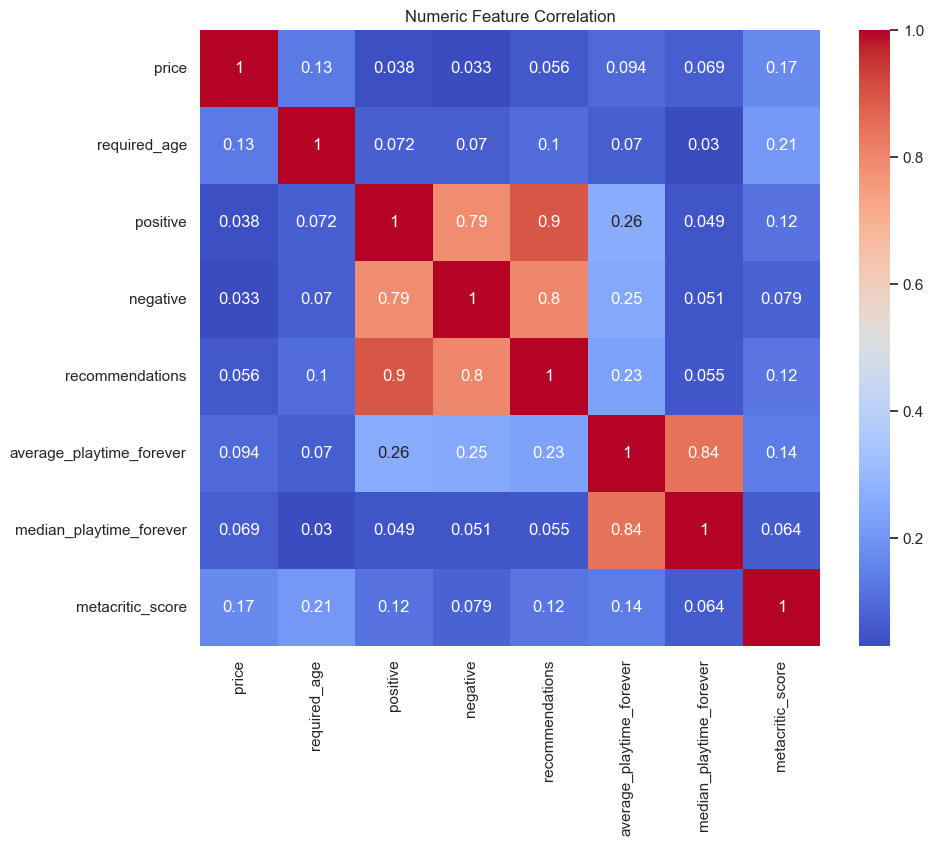

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# 数值型特征列
numeric_cols = ['price','required_age','positive','negative','recommendations',
                'average_playtime_forever','median_playtime_forever','metacritic_score']

# 绘制相关性热力图
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Numeric Feature Correlation")  # 图表标题
plt.show()


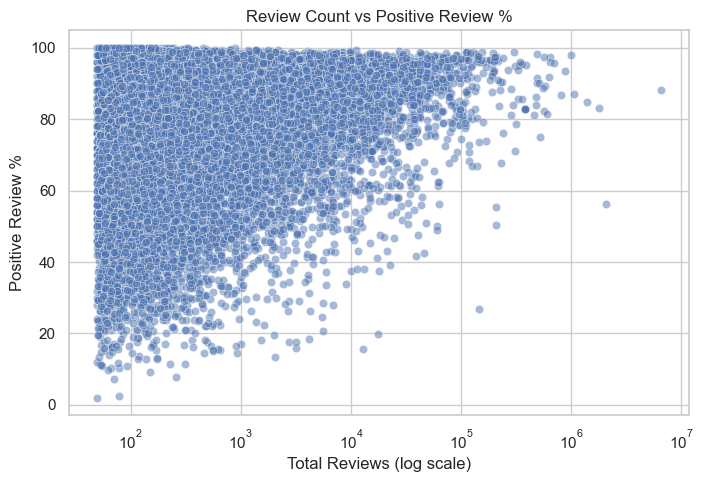

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# 绘制总评价数与好评率的散点图
plt.figure(figsize=(8, 5))
sns.scatterplot(x='total_reviews', y='positive_percent', data=df_filtered, alpha=0.5)

# 使用对数坐标轴，便于展示差异较大的数据
plt.xscale('log')
plt.xlabel("Total Reviews (log scale)")
plt.ylabel("Positive Review %")
plt.title("Review Count vs Positive Review %")
plt.show()


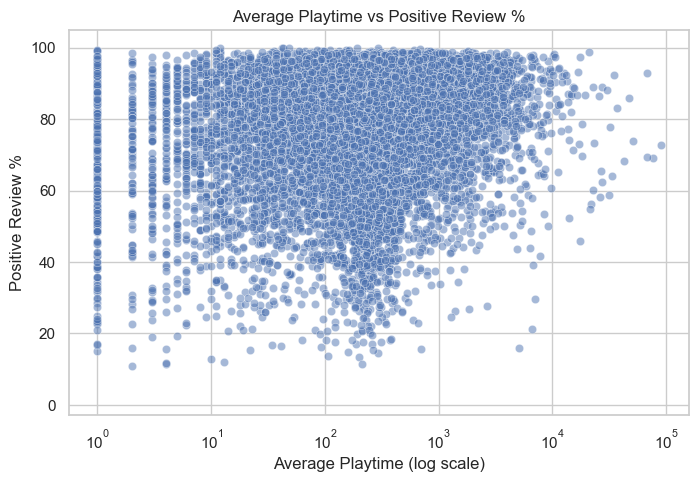

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# 绘制平均游玩时长与好评率的散点图
plt.figure(figsize=(8, 5))
sns.scatterplot(x='average_playtime_forever', y='positive_percent', data=df_filtered, alpha=0.5)

# 使用对数坐标，更好展示长尾分布
plt.xscale('log')
plt.title("Average Playtime vs Positive Review %")
plt.xlabel("Average Playtime (log scale)")
plt.ylabel("Positive Review %")
plt.show()


In [40]:
# 计算每个热门标签对应游戏的平均好评率
top_tag_list = [tag for tag, _ in top_tags]

for tag in top_tag_list:
    # 选出包含该标签的游戏
    tag_games = df[df['tags'].str.contains(tag, na=False)]
    
    # 输出该标签的平均好评率
    print(f"{tag}: 平均好评率 = {tag_games['positive_percent'].mean():.2f}%")


Indie: 平均好评率 = 75.47%
Singleplayer: 平均好评率 = 79.47%
Action: 平均好评率 = 75.62%
Adventure: 平均好评率 = 76.49%
Casual: 平均好评率 = 76.67%
2D: 平均好评率 = 82.72%
RPG: 平均好评率 = 75.36%
Strategy: 平均好评率 = 74.67%
Platformer: 平均好评率 = 81.19%
3D: 平均好评率 = 76.98%


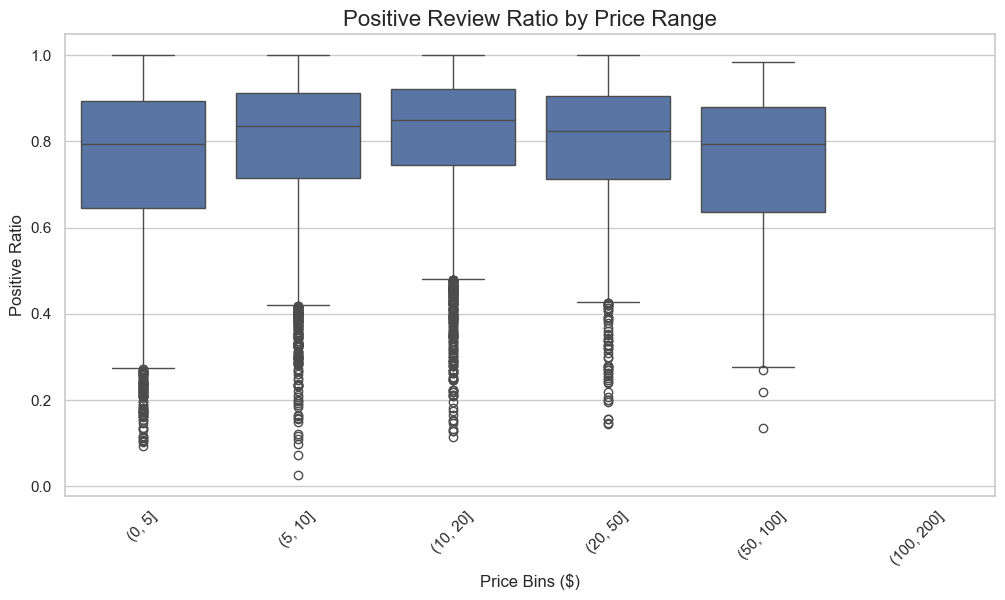

In [41]:
# 确保 'positive_ratio' 字段已经存在
df_filtered = df_filtered.copy()
df_filtered.loc[:, 'positive_ratio'] = df_filtered['positive'] / (df_filtered['positive'] + df_filtered['negative'])

# 对价格进行分箱
df_filtered.loc[:, 'price_bin'] = pd.cut(df_filtered['price'], bins=[0,5,10,20,50,100,200])

# 绘制箱线图
plt.figure(figsize=(12, 6))
sns.boxplot(x='price_bin', y='positive_ratio', data=df_filtered)
plt.xticks(rotation=45)
plt.title("Positive Review Ratio by Price Range", fontsize=16)
plt.xlabel("Price Bins ($)", fontsize=12)
plt.ylabel("Positive Ratio", fontsize=12)
plt.show()

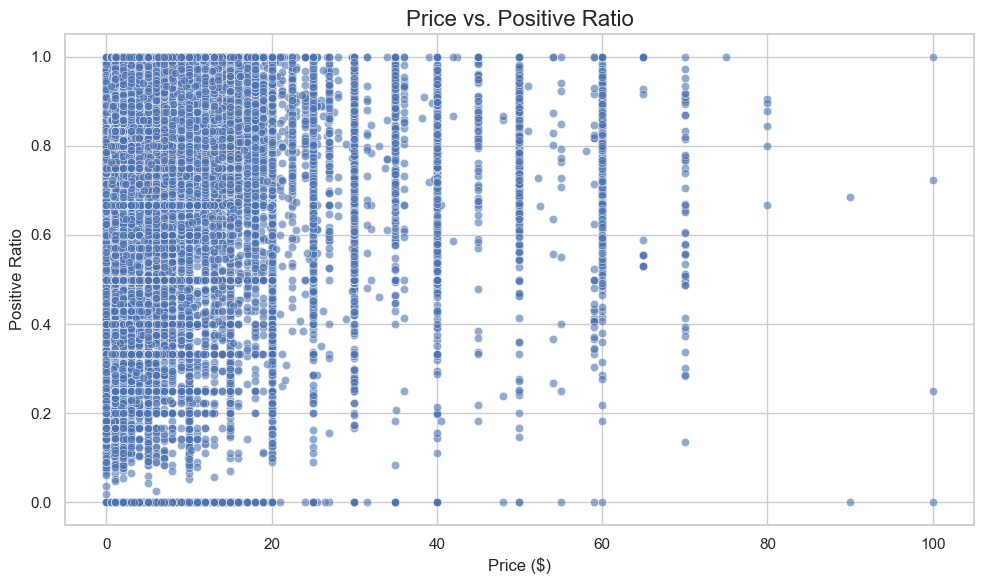

价格与好评率的皮尔逊相关系数：0.06
相关性非常弱，价格与好评率之间没有明显的线性关系。


In [42]:
# 首先，计算好评率
df['positive_ratio'] = df['positive'] / (df['positive'] + df['negative'])

# 移除 reviews 总数为 0 的行，避免 NaN 值
df_filtered = df.loc[df['positive'] + df['negative'] > 0]

# 过滤掉价格过高的异常值，让图表更清晰
# 绝大多数游戏价格低于 100 美元，我们关注这部分数据
df_filtered = df_filtered[df_filtered['price'] < 100]

# 绘制价格与好评率的散点图
plt.figure(figsize=(10, 6))
sns.scatterplot(x='price', y='positive_ratio', data=df_filtered, alpha=0.6)
plt.title('Price vs. Positive Ratio', fontsize=16)
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Positive Ratio', fontsize=12)
plt.tight_layout()
plt.show()

# 计算相关系数
correlation = df_filtered['price'].corr(df_filtered['positive_ratio'])
print(f"价格与好评率的皮尔逊相关系数：{correlation:.2f}")
if abs(correlation) < 0.2:
    print("相关性非常弱，价格与好评率之间没有明显的线性关系。")

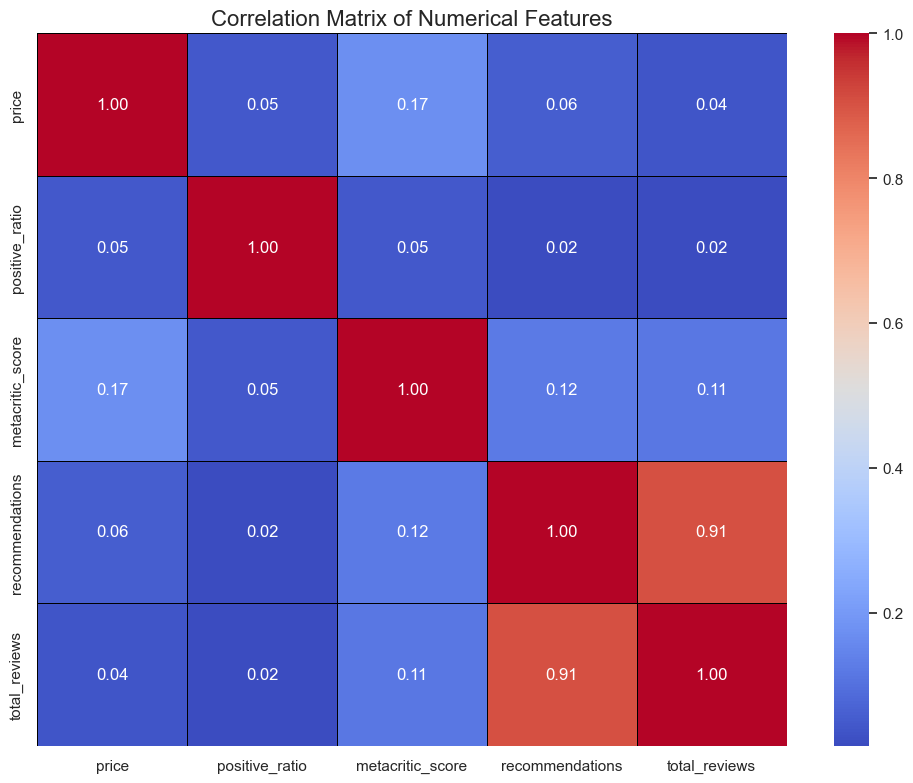

In [43]:
# 筛选出需要分析的数值特征
numerical_features = ['price', 'positive_ratio', 'metacritic_score', 'recommendations', 'total_reviews']

# 过滤掉 NaN 值以进行相关性分析
corr_df = df[numerical_features].dropna()
correlation_matrix = corr_df.corr()

# 绘制相关性热力图
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=.5, linecolor='black')
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()